# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [1]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw

In [2]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [3]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")
OUTPUT_PATH_WS = os.path.join(OUTPUT_PATH, "watts_strogatz_model")
OUTPUT_PATH_COMMUNITIES = os.path.join(OUTPUT_PATH, "communities")
OUTPUT_PATH_POWER_LAWS = os.path.join(OUTPUT_PATH, "power_laws")

# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)
os.makedirs(OUTPUT_PATH_WS)
os.makedirs(OUTPUT_PATH_COMMUNITIES)
os.makedirs(OUTPUT_PATH_POWER_LAWS)

In [4]:
# Define the directory containing the .gml files
directory = 'assignment_02_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  43%|████▎     | 3/7 [00:07<00:07,  1.88s/it]

Finished loading graph_internet
Finished loading graph_Korea
Finished loading graph_eu_airlines
Finished loading graph_macaque


Loading GML Files: 100%|██████████| 7/7 [00:35<00:00,  5.11s/it]

Finished loading graph_hep-th
Finished loading graph_starwars
Finished loading graph_madrid


# I Erdos-Renyi Model

In [5]:
graphs

{'graph_internet': <networkx.classes.graph.Graph at 0x12275bfd0>,
 'graph_Korea': <networkx.classes.graph.Graph at 0x1200d3710>,
 'graph_eu_airlines': <networkx.classes.graph.Graph at 0x120457cd0>,
 'graph_macaque': <networkx.classes.graph.Graph at 0x1201fcfd0>,
 'graph_hep-th': <networkx.classes.graph.Graph at 0x12a5cbfd0>,
 'graph_starwars': <networkx.classes.graph.Graph at 0x1220cbd50>,
 'graph_madrid': <networkx.classes.graph.Graph at 0x1222d3d50>}

## 1. Write a function to generate an Erdős-Rényi undirected graph G(N, p).
It should take in two input parameters:
- N: the number of nodes of the network,
- p: the probability of an edge existing between two nodes,

and it should output a network (the data structure to represent the network is left to your choice, in the
hint a suggestion is provided).

In [6]:
random.seed(a=42)

In [7]:
def generate_custom_erdos_renyi_graph(N, p):
    # Precondition
    if p < 0 or p > 1:
        raise ValueError("Probability p must be in the range [0, 1]")
    

    # Create a graph object
    G = nx.Graph()
    
    # Init N nodes 
    G.add_nodes_from(range(N))

    # Model: each pair of 𝑁 nodes is connected with edge creation probability 𝑝
    for i in range(N):
        for j in range(i + 1, N):
            # In total: N (N-1) * 0.5 possible links
            if random.random() < p: # Select node with probability p
                G.add_edge(i, j)

    return G

## 2. Using the function you wrote at point (1), generate three Erdős-Rényi networks with N = 100 nodes and link probability 
- (a) p = 0.001,
- (b) p = 0.01,
- (c) p = 0.1, and
- (d) p = 0.5.

Provide a visualisation of these networks, in order to emphasize the existence of connected components.

In [8]:
SEED = 42
N = 100
PROBABILITIES = [0.001, 0.01, 0.1, 0.5]

In [9]:
generated_networks = []

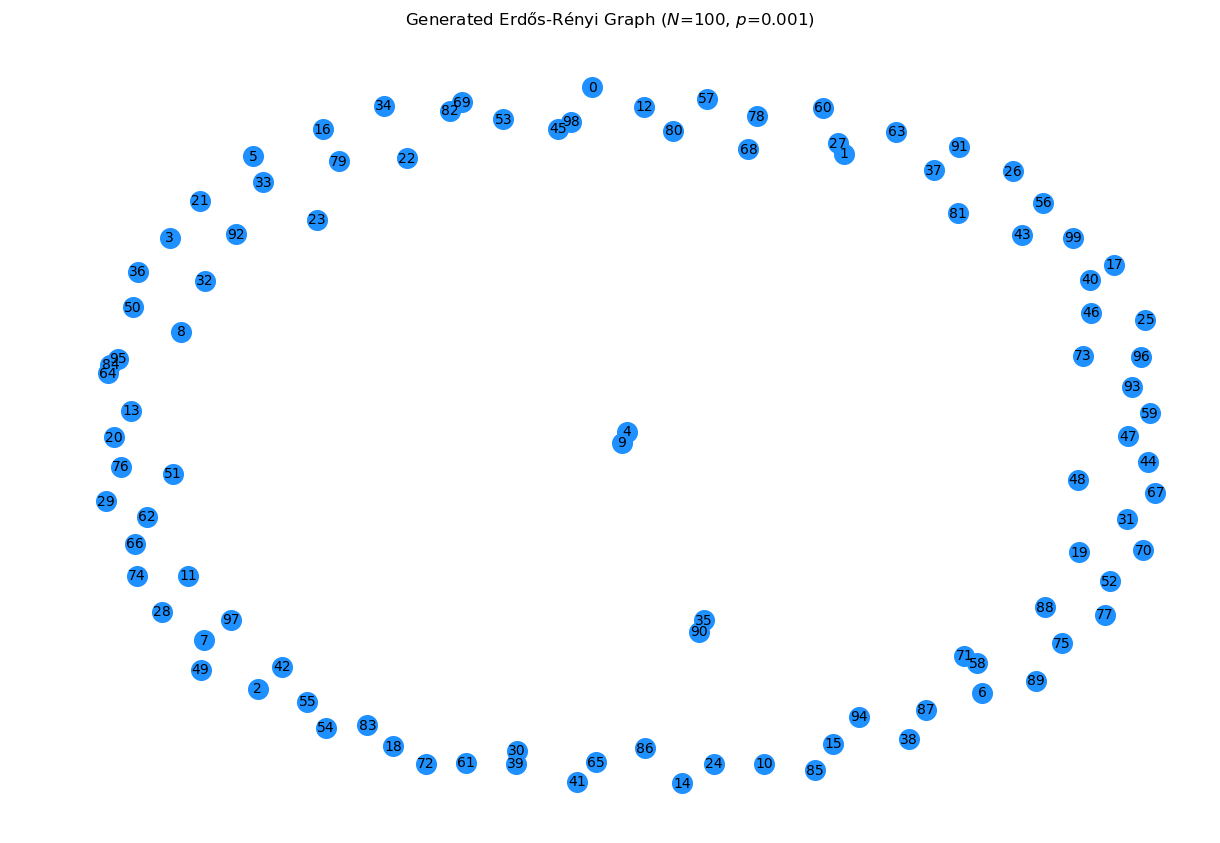

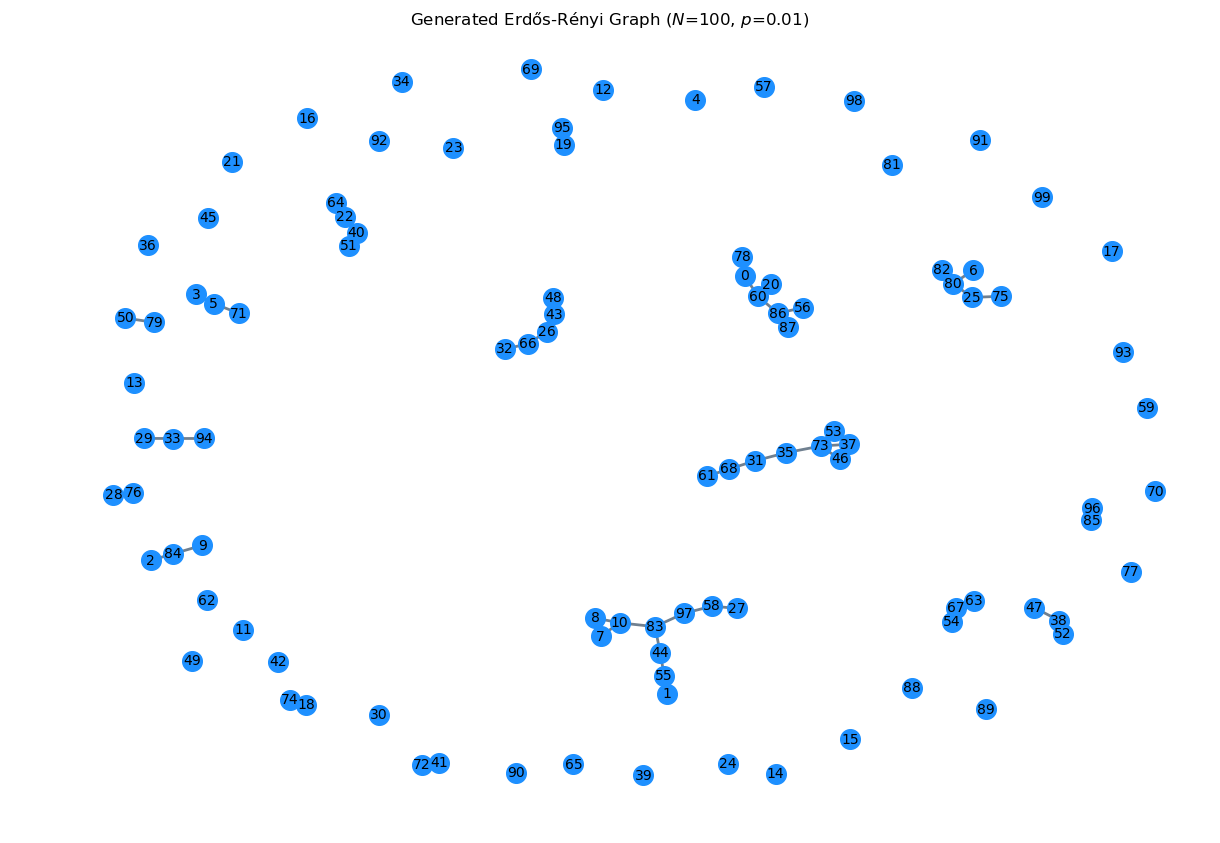

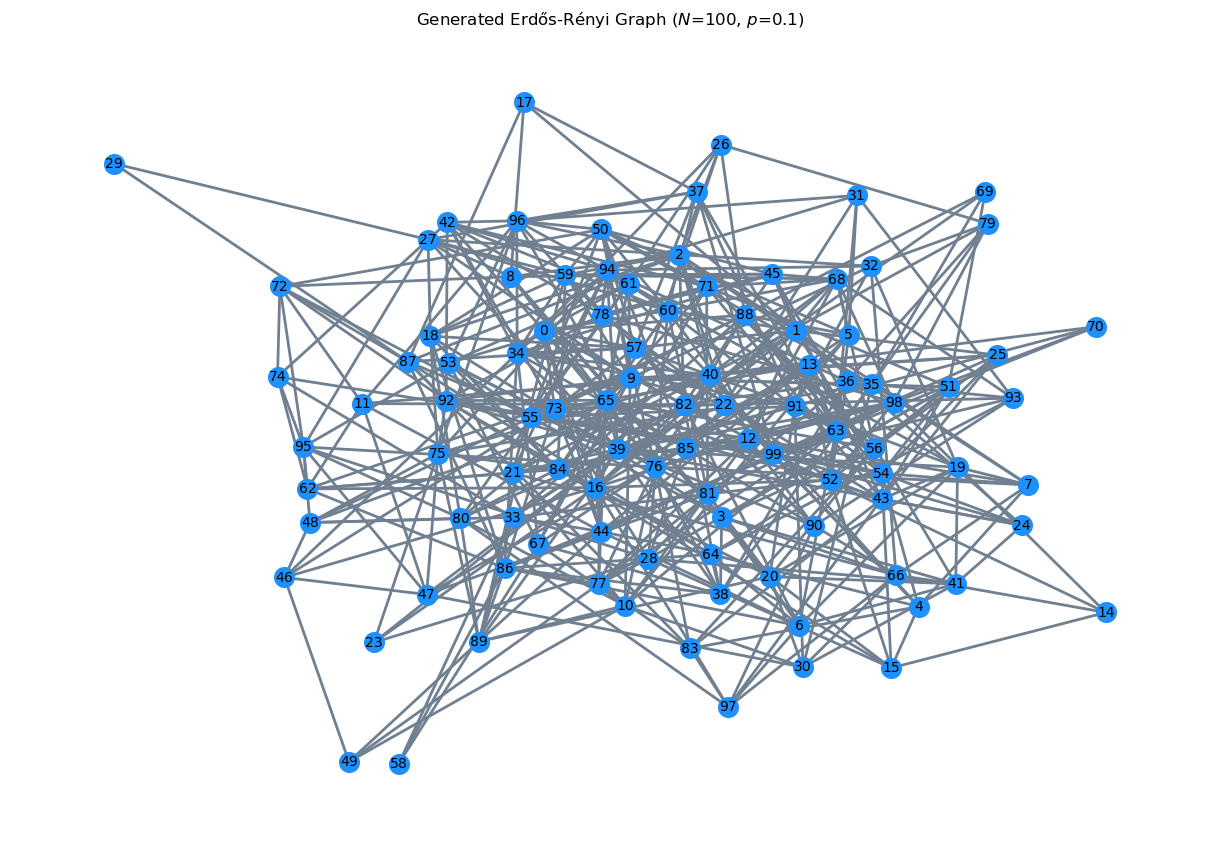

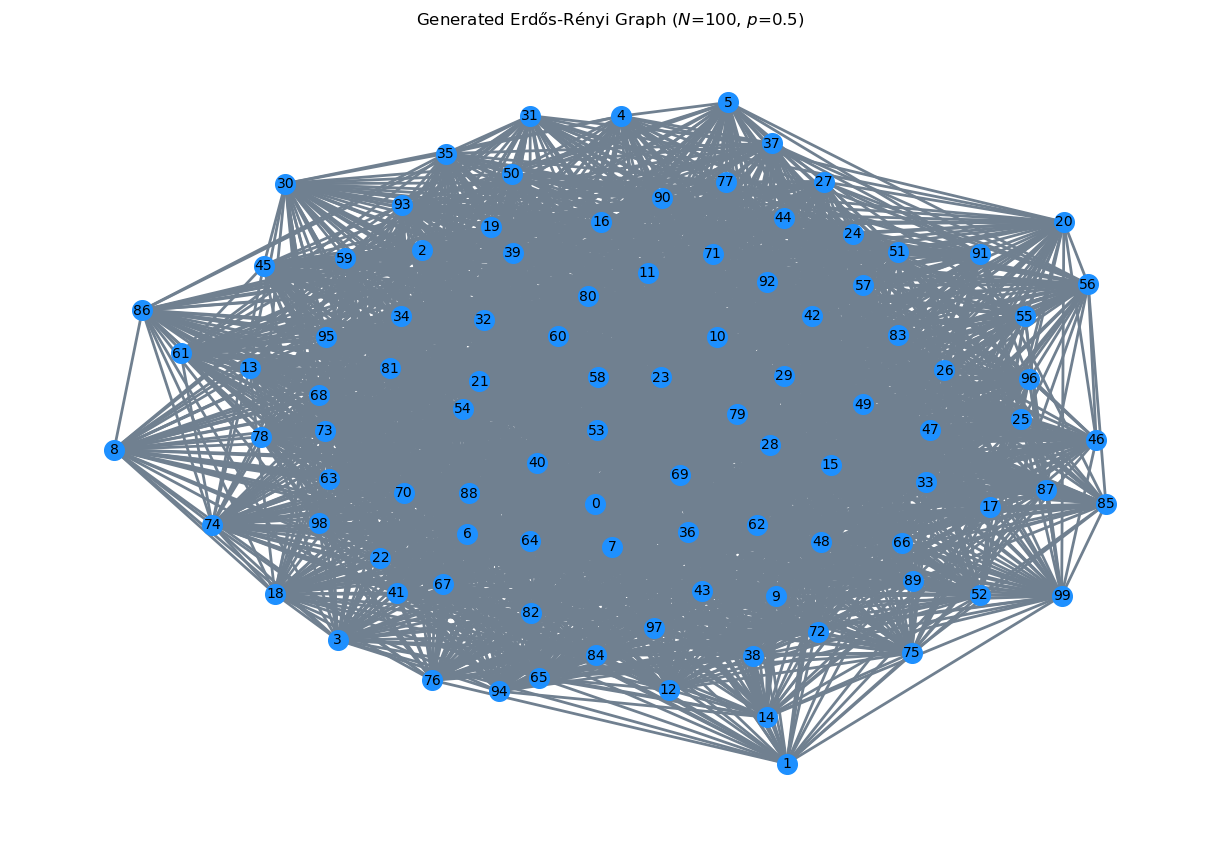

In [10]:
for p in PROBABILITIES:
    g = generate_custom_erdos_renyi_graph(N, p)
    generated_networks.append({"graph":g, "N": N, "p": p})
    pos = nx.spring_layout(G=g, seed=SEED)  # Layout algorithm for node positions
    plt.figure(figsize=(12, 8))
    nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
    plt.title(fr"Generated Erdős-Rényi Graph ($N$={N}, $p$={p})")
    plt.axis('off')
    
    file_name = f"sample_network_N{N}_p{p}.png"
    complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

## 3. Generate ER graphs with N = 100 nodes for different edge creation probabilities p ∈ [0, 1] and plot the probability that a node belongs to the largest connected component NG/N as a function of p and mark with a vertical line the critical probability pC = 1/N.

In [11]:
N = 100
sample_size = 100
probabilities_log_range = np.logspace(-5, 0, 200)

In [12]:
# Clustering for 1.4 (handeled in the same loop)

ratios_avg = {}
clusters_average = {}
for p in probabilities_log_range:
    ratios = []
    clusters = []
    for n in range(sample_size):
        # Generate ER graph samples for each p
        g = generate_custom_erdos_renyi_graph(N,p)
        
        # Get all components
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
        connected_components = sorted(nx.connected_components(g), key=len, reverse=True)
        
        # Get largest connected component (LCC)
        largest_connected_component = g.subgraph(connected_components[0])
        
        # Find size of lcc
        nodes_lcc = largest_connected_component.number_of_nodes()
        
        # Calculate ration N_G / N
        ratio = float(nodes_lcc / len(g))
        
        # Append to ratio sample list
        ratios.append(ratio)

        # Add cluster for each graph
        clusters.append(nx.average_clustering(g))
    
    # Average all results in ratios to get value for a specific p
    ratios_avg[f"{p}"] = mean(ratios)

    # Average in the clusters
    clusters_average[f"{p}"] = mean(clusters)

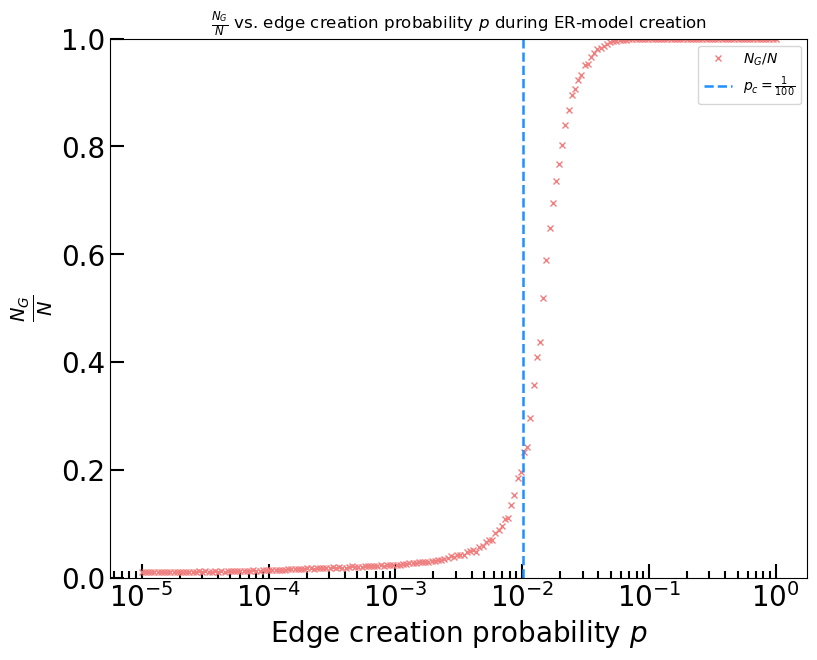

In [13]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111)

ax.plot(probabilities_log_range, np.array(list(ratios_avg.values())), "x",  ms=5,color=COLOR_RED, label=r"$N_G / N$") # Regular values ### Converted ratios_avg.values to array because before they were dict_values and plottign was not possible
plt.axvline(x=1./(N-1),linestyle="--", lw="1.8",color=COLOR_BLUE, label=f'$ p_c = \\frac{{1}}{{{N}}}$') # Horizontal line p_c = 1 / N

# Formatting
plt.title(r"$\frac{N_G}{N}$ vs. edge creation probability $p$ during ER-model creation")
ax.set_xlabel(r"Edge creation probability $p$", fontsize=20)
ax.set_ylabel(r"$\frac{N_G}{N}$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")
plt.legend()

file_name = "average_ng_vs_n_ratio_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()


## 4. Plot the average clustering ⟨c⟩ as a function of p and give an interpretation of the result.

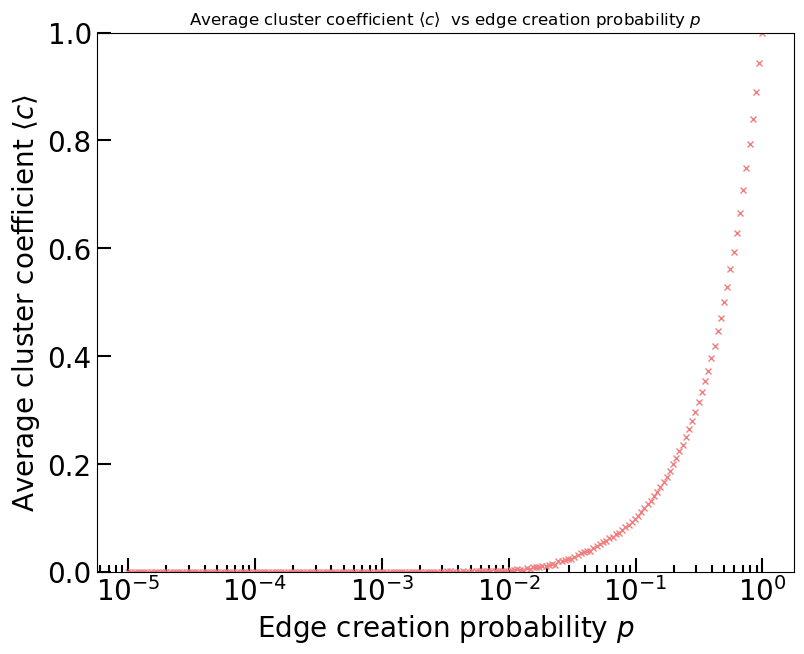

In [14]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111)
ax.plot(probabilities_log_range, np.array(list(clusters_average.values())), "x",  ms=5,color=COLOR_RED) # Regular values ### Converted clusters_average.values to array because before they were dict_values and plottign was not possible

# Formatting
plt.title(r"Average cluster coefficient $\langle c \rangle$  vs edge creation probability $p$")
ax.set_xlabel(r"Edge creation probability $p$", fontsize=20)
ax.set_ylabel(r"Average cluster coefficient $\langle c \rangle$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")

file_name = "average_cluster_vs_p_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()

Interpretation: As p increases, so does the clustering within the network, This aligns with our expectations because a higher p imples a greater number of edges between nodes. With this the network gets denser and the clustering coefficient indicates a denser network.

# II Watts-Strogatz Model

## 1. Write a function to generate a one-dimensional lattice with periodic boundary conditions and coordination
number k, defined as we saw in the class and assignment 1. The function should take in input two parameters:
- N: the number of nodes of the lattice,
- k: the coordination number,

and it should output a network (the data structure to represent the network is left to your choice, in the hint a suggestion is provided). You have to implement the algorithm yourself and cannot rely on modules’ functions.
Finally, produce a visualisation of a network generated using such function, with
N = 21 and k = 5.

In [15]:
random.seed(42)

In [16]:
def generate_one_dim_lattice(N, k):
    # Precondition
    if k >= N:
        raise ValueError("Coordination number k must not be larger or equal than the number of nodes in the lattice N.")

    # Create a graph object
    G = nx.Graph()
    
    # Init N nodes 
    G.add_nodes_from(range(1, N+1, 1))

    # Connect the nodes
    for i in range(1, N+1, 1):
        current_node = i
        
        # Forward edges
        for j in range(i + 1, i + k + 1, 1):
            G.add_edge(current_node, j if j <= N else j % N)  # else case handles the overflow

        # Backward edges
        for j in range(i - 1, i - k - 1, -1):
            G.add_edge(current_node, j if j > 0 else N - (abs(j) % N)) # else case handles the overflow

    return G

In [17]:
N = 21
k = 5

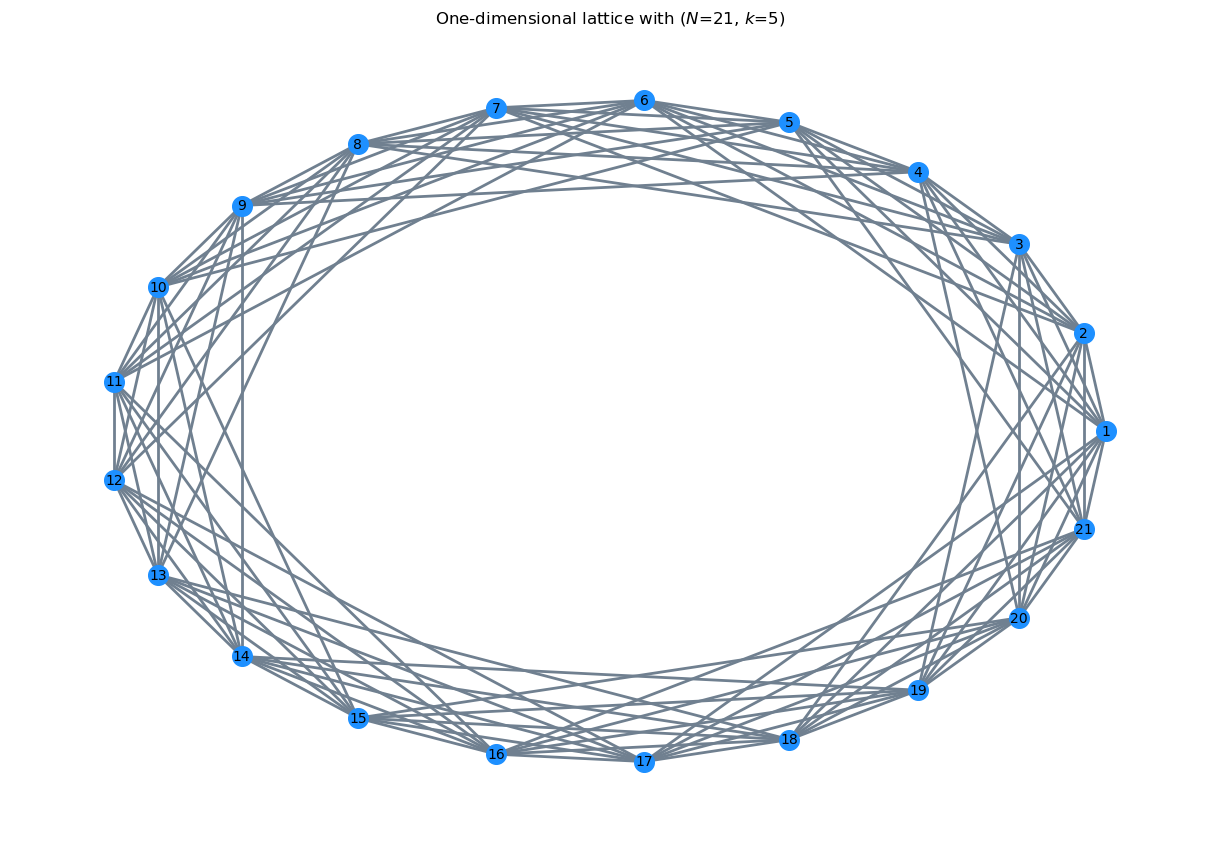

In [18]:
g = generate_one_dim_lattice(N=N, k=k)
pos = nx.circular_layout(G=g)  # Layout algorithm for node positions
plt.figure(figsize=(12, 8))
nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
plt.axis("off")
plt.title(fr"One-dimensional lattice with ($N$={N}, $k$={k})")
file_name = f"one_dim_lattice_N{N}_k{k}.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

## 2. Produce a plot of the average distance of each graph in a sequence of one-dimensional periodic lattices generated using the function you wrote at point 1,
where k = 10 is fixed and on the x-axis N ranges between 50 and 1000.
What is the relation between the average distance and the number of nodes?
Does it meet your expectations? Provide an interpretation of the plot.

In [19]:
k = 10

N = range(50, 1001, 1)

In [20]:
avg_shortest_paths = []

In [21]:
for n in tqdm(N, desc="Calculating Average Shortest Paths"):
    lattice = generate_one_dim_lattice(N=n, k=k)
    
    # Calculate the average shortest path
    avg_shortest_path = nx.average_shortest_path_length(G=lattice)
    avg_shortest_paths.append(avg_shortest_path)

Calculating Average Shortest Paths: 100%|██████████| 951/951 [08:44<00:00,  1.81it/s]


In [22]:
# Calculate the values with the formula from assignment 1
calculated_avg_nodes = []
calculated_avg_distances = []

for i, avg_shortest_path in enumerate(avg_shortest_paths):
    n = i+50
    if (n % 2 != 0) and ((n - 1) / (2 * k)).is_integer():
        d = (n-1 + 2*k) / (4*k)
        calculated_avg_nodes.append(n)
        calculated_avg_distances.append(d)
        

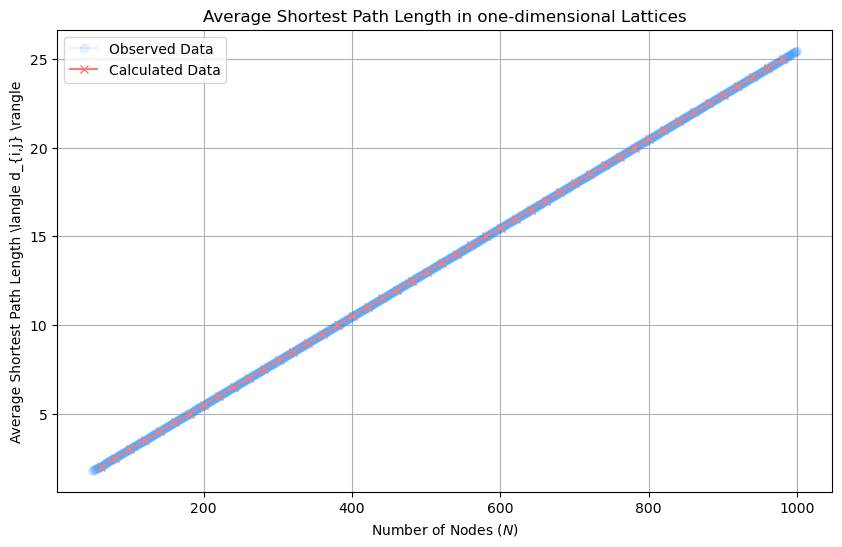

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(N, avg_shortest_paths, marker="o", linestyle="-", color=COLOR_BLUE, label='Observed Data', alpha=0.1)
plt.plot(calculated_avg_nodes, calculated_avg_distances, marker='x', linestyle='-', color=COLOR_RED, label='Calculated Data', alpha=1.0)
plt.title("Average Shortest Path Length in one-dimensional Lattices")
plt.xlabel(r"Number of Nodes ($N$)")
plt.ylabel(r"Average Shortest Path Length \langle d_{i,j} \rangle")
plt.legend()
plt.grid(True)
file_name = f"average_shortest_path_one_dim_lattice.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

Does it meet your expectations?

Yes, the observed data, that was generated with the `generate_one_dim_lattice()` function is clearly aligned with the calculated values forme the formula in Assignment 1.


Provide an interpretation of the plot.
We have observed a linear dependency, specifically a positive correlation, between the number of nodes $N$ and the average shortest path length $\langle d_{i,j} \rangle$. This correlation is governed by the following formula:

When $N$ is odd and $\frac{N-1}{2k}$ is an integer:
$$ \langle d_{i,j} \rangle = \frac{N-1+2k}{4k} $$

The formula demonstrates that when $N$ satisfies the given conditions, the average shortest path length is determined by the expression $\frac{N-1+2k}{4k}$. In cases where $N$ falls between integer values, the plot shows a clear interpolation between data points.

## 3. Implement the original Watts-Strogatz Watts and Strogatz [1998] model, following the example we saw in the slides. It should take in input three parameters:
- $N$: the number of nodes of the network,
- $k$: the coordination number of the $1-d$ original lattice with periodic condition,
- $p$: the rewiring probability,

and it should output a network (the data structure to represent the network is left to your choice, in the hint a useful suggestion is provided). Implement the algorithm yourself and do not rely on networkx/third parties module functions. Finally, plot the network generated using such a function, for $N = 21$, $p = 0.1$, $k = 5$, using a circular layout.

You want to make sure no self-loops and multi-edges (multiple edges between the same two nodes)
happen.

In [24]:
N = 21
p = 0.1
k = 5

In [25]:
def generate_custom_watts_strogatz_graph(N, k, p, debug=False):
    # Precondition
    if p < 0 or p > 1:
        raise ValueError("Probability p must be in the range [0, 1]")
    
    g = generate_one_dim_lattice(N=N, k=k)
    
    if debug:
                plt.figure(figsize=(12, 8))
                nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
                plt.axis("off")
                plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
                plt.show()
    
    
    nodes = list(g.nodes())
    first_node = nodes[0]
    last_node = nodes[-1]
    #print(first_node, last_node)
    
    
    # TODO: can we use g.edges?
    for node in nodes:
        edges = list(g.edges(node))
        #print(f"Edges connected to node {node}: {edges}")
        
        # Initialize potential_targets for this node
        # no self-loops and multi-edges (multiple edges between the same two nodes)
        potential_targets = list(set(g.nodes()) - set([node]) - set(g.neighbors(node)))
        
        for edge in edges:
            source_node, old_target_node = edge
            
            # no self-loops and multi-edges (multiple edges between the same two nodes)
            # very slow
            # potential_targets = list(set(g.nodes()) - set([source_node]) - set(g.neighbors(source_node)))
            #print(potential_targets)
            
            
            if random.random() < p: # Change edge with probability p
                #print("Change")
                new_target_node = random.choice(potential_targets)
                #print(new_target_node)
                
                # Rewire
                g.remove_edge(source_node, old_target_node)
                g.add_edge(source_node, new_target_node)
                
                # Update potential_targets after rewiring
                potential_targets.remove(new_target_node)
                potential_targets.append(old_target_node)
                
                if debug:
                    print(f"changed {source_node} -> {old_target_node} to {source_node} -> {new_target_node}")
                    
                    
            else:
                if debug:
                    print("did not change anything")
                else:
                    pass
                
            #print(f"Edges connected to node {node}: {edges}")
            
            if debug:
                plt.figure(figsize=(12, 8))
                nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
                plt.axis("off")
                plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
                plt.show()
    return g

In [26]:
ws_graph = generate_custom_watts_strogatz_graph(N=N, k=k, p=p, debug=False)

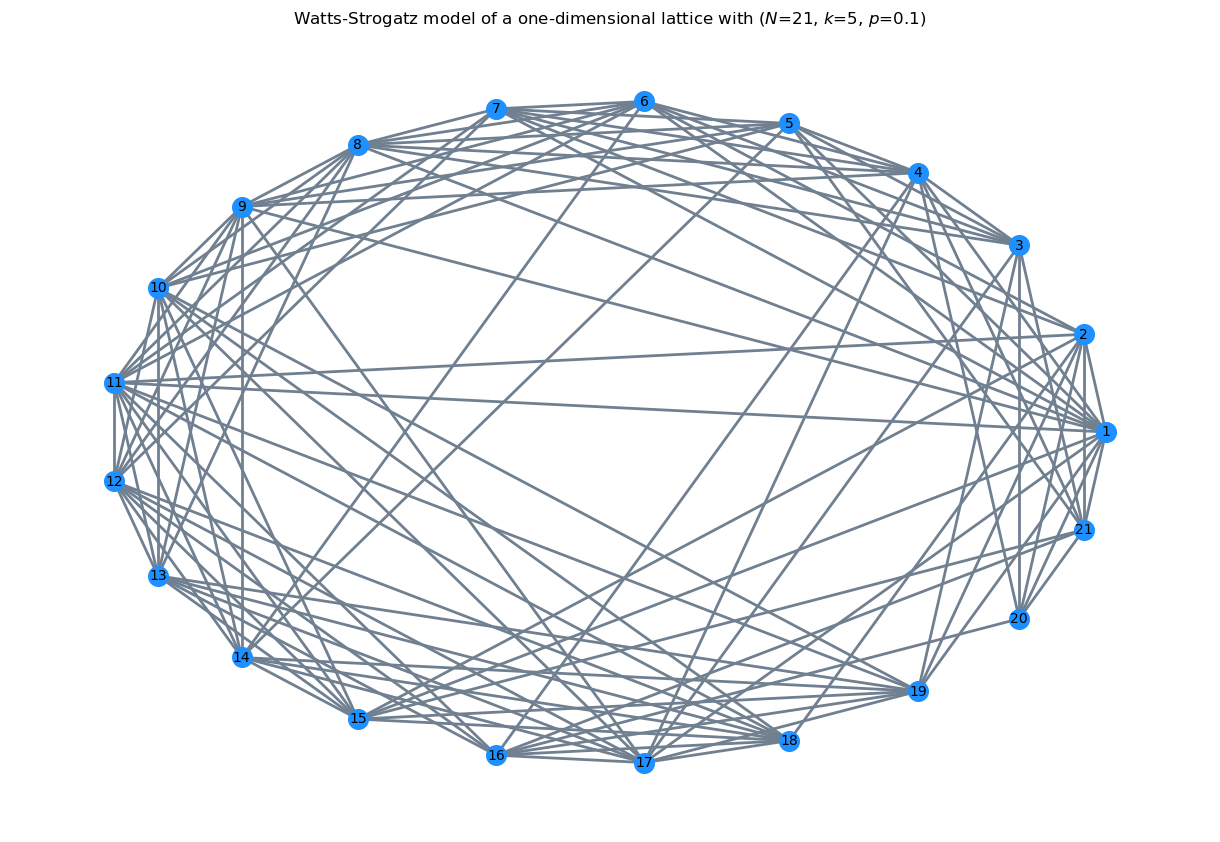

In [27]:
pos = nx.circular_layout(G=ws_graph)  # Layout algorithm for node positions
plt.figure(figsize=(12, 8))
nx.draw(ws_graph, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)

plt.axis("off")
plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
file_name = f"watts_strogatz_model_example_one_dim_lattice_N{N}_k{k}_p{p}.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

## 4. Compute and plot $L$, the average distance (we are painfully aware that the same measure was denoted as Copy code $\langle d_{i,j} \rangle$ in the previous assignment nonetheless we opted for the use of $L$ in this exercise to be faithful to the original notation used in Watts and Strogatz [1998]), and $c$, the global clustering coefficient on a sample of networks generated from the Watts-Strogatz model (using the python function you wrote in the previous point), as a function of $p \in [0, 1]$ (the rewiring parameter), keeping $N = 1000$ and $k = 10$ fixed.

In [28]:
N = 1000
k = 10
sample_size = 100
probabilities_log_range = np.logspace(-5, 0, 50)

In [29]:
avg_shortest_path_averages = {}
avg_clustering_coefficients = {}
def compute_metrics(p):
    avg_shortest_paths = []
    clustering_coefficients = []

    for n in range(sample_size):
        # Generate custom WS graph samples for each p
        g = generate_custom_watts_strogatz_graph(N=N, k=k, p=p, debug=False)

        if nx.is_connected(g):
            # Calculate the shortest path length
            avg_shortest_path = nx.average_shortest_path_length(g)
            avg_shortest_paths.append(avg_shortest_path)

            # Calculate clustering coefficient
            clustering_coefficient = nx.average_clustering(g)
            clustering_coefficients.append(clustering_coefficient)

    avg_shortest_path_avg = mean(avg_shortest_paths)
    avg_clustering_coefficient = mean(clustering_coefficients)

    return p, avg_shortest_path_avg, avg_clustering_coefficient

results = Parallel(n_jobs=-1)(delayed(compute_metrics)(p) for p in tqdm(probabilities_log_range, desc="Processing p values"))

for p, avg_shortest_path_avg, avg_clustering_coefficient in results:
    avg_shortest_path_averages[f"{p}"] = avg_shortest_path_avg
    avg_clustering_coefficients[f"{p}"] = avg_clustering_coefficient

Processing p values: 100%|██████████| 50/50 [31:14<00:00, 37.49s/it]


In [30]:
print(avg_shortest_path_averages)
print(avg_clustering_coefficients)

{'1e-05': 25.076192632632633, '1.2648552168552958e-05': 24.302342882882883, '1.5998587196060572e-05': 24.246943263263265, '2.0235896477251556e-05': 24.054023863863865, '2.559547922699533e-05': 23.8606982982983, '3.237457542817647e-05': 23.31334990990991, '4.094915062380427e-05': 22.732173673673675, '5.1794746792312125e-05': 22.11395793793794, '6.55128556859551e-05': 21.489159099099098, '8.286427728546843e-05': 20.78516072072072, '0.00010481131341546853': 18.885274734734736, '0.00013257113655901095': 18.639127267267266, '0.00016768329368110083': 16.899543243243244, '0.00021209508879201905': 15.775756736736737, '0.0002682695795279727': 14.00987881881882, '0.000339322177189533': 12.848824624624624, '0.00042919342601287783': 11.895311631631632, '0.0005428675439323859': 10.488722562562563, '0.0006866488450042998': 9.70587957957958, '0.000868511373751353': 8.795352292292293, '0.0010985411419875584': 7.960076756756757, '0.0013894954943731374': 7.42214976976977, '0.001757510624854793': 6.82520

In [31]:
# This is only done to compare the results

avg_shortest_path_averages_built_in = {}
avg_clustering_coefficients_built_in = {}
def compute_metrics_built_in(p):
    avg_shortest_paths_built_in = []
    clustering_coefficients_built_in = []
    
    for n in range(sample_size):
        # Generate ER graph samples for each p
        g = nx.watts_strogatz_graph(n=N, k=k, p=p)
    
        if nx.is_connected(g):
            # Calculate the shortest path length
            avg_shortest_path = nx.average_shortest_path_length(g)
            avg_shortest_paths_built_in.append(avg_shortest_path)
    
            # Calculate clustering coefficient
            clustering_coefficient = nx.average_clustering(g)
            clustering_coefficients_built_in.append(clustering_coefficient)
    
    avg_shortest_path_avg = mean(avg_shortest_paths_built_in)
    avg_clustering_coefficient = mean(clustering_coefficients_built_in)
    
    return p, avg_shortest_path_avg, avg_clustering_coefficient

results = Parallel(n_jobs=-1)(delayed(compute_metrics_built_in)(p) for p in tqdm(probabilities_log_range, desc="Processing p values"))

for p, avg_shortest_path_avg, avg_clustering_coefficient in results:
    avg_shortest_path_averages_built_in[f"{p}"] = avg_shortest_path_avg
    avg_clustering_coefficients_built_in[f"{p}"] = avg_clustering_coefficient
    

Processing p values: 100%|██████████| 50/50 [19:02<00:00, 22.86s/it]


In [32]:
print(avg_shortest_path_averages_built_in)
print(avg_clustering_coefficients_built_in)

{'1e-05': 49.97457347347348, '1.2648552168552958e-05': 49.95307755755756, '1.5998587196060572e-05': 49.63228570570571, '2.0235896477251556e-05': 49.39803707707708, '2.559547922699533e-05': 49.4711535935936, '3.237457542817647e-05': 49.50168786786787, '4.094915062380427e-05': 49.461791151151154, '5.1794746792312125e-05': 48.06825597597598, '6.55128556859551e-05': 47.39859273273274, '8.286427728546843e-05': 46.909549169169175, '0.00010481131341546853': 47.91472146146146, '0.00013257113655901095': 45.49842514514515, '0.00016768329368110083': 44.32780460460461, '0.00021209508879201905': 43.561526006006005, '0.0002682695795279727': 42.34417863863864, '0.000339322177189533': 38.290528168168166, '0.00042919342601287783': 36.26813401401402, '0.0005428675439323859': 35.252444844844845, '0.0006866488450042998': 33.26667119119119, '0.000868511373751353': 28.785162182182184, '0.0010985411419875584': 26.47550952952953, '0.0013894954943731374': 23.240005705705705, '0.001757510624854793': 20.87424766

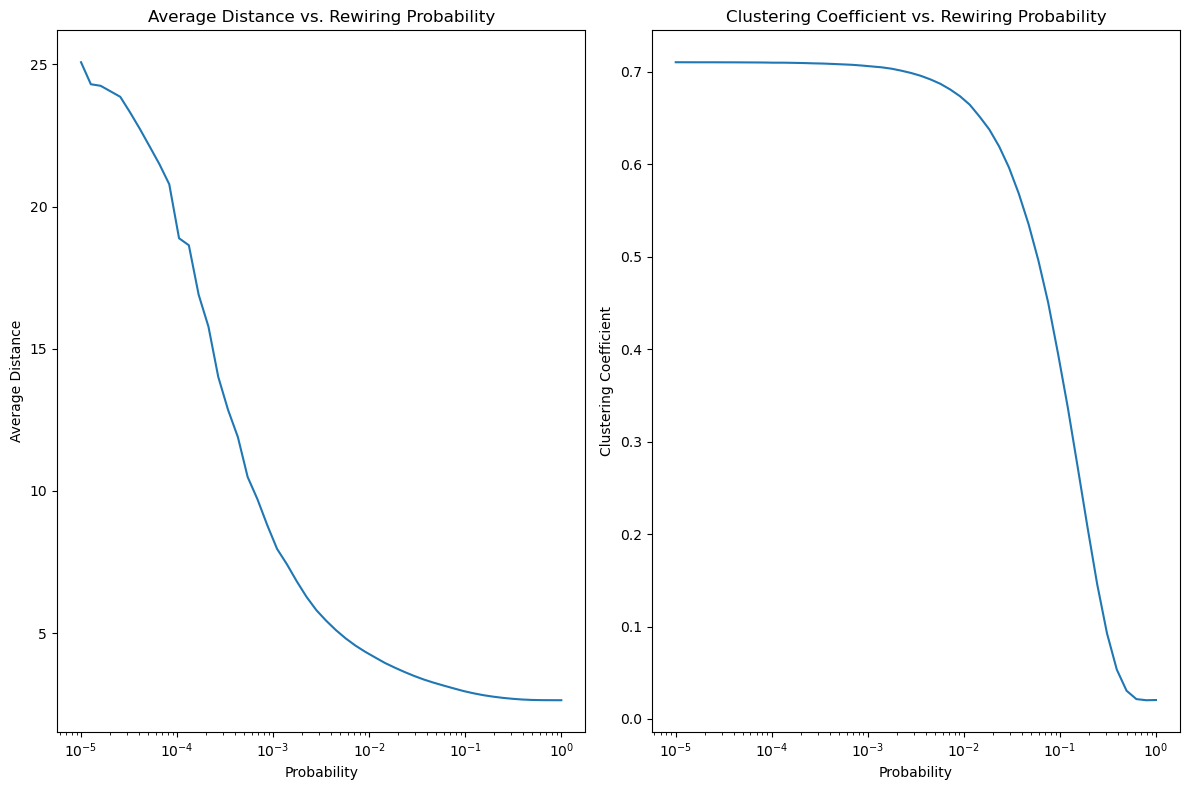

In [33]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.semilogx(probabilities_log_range, avg_shortest_path_averages.values())
plt.xlabel('Probability')
plt.ylabel('Average Distance')
plt.title('Average Distance vs. Rewiring Probability')

plt.subplot(1, 2, 2)
plt.semilogx(probabilities_log_range, avg_clustering_coefficients.values())
plt.xlabel('Probability')
plt.ylabel('Clustering Coefficient')
plt.title('Clustering Coefficient vs. Rewiring Probability')
plt.tight_layout()

file_name = f"watts_strogatz_model_average_paths_and_communities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

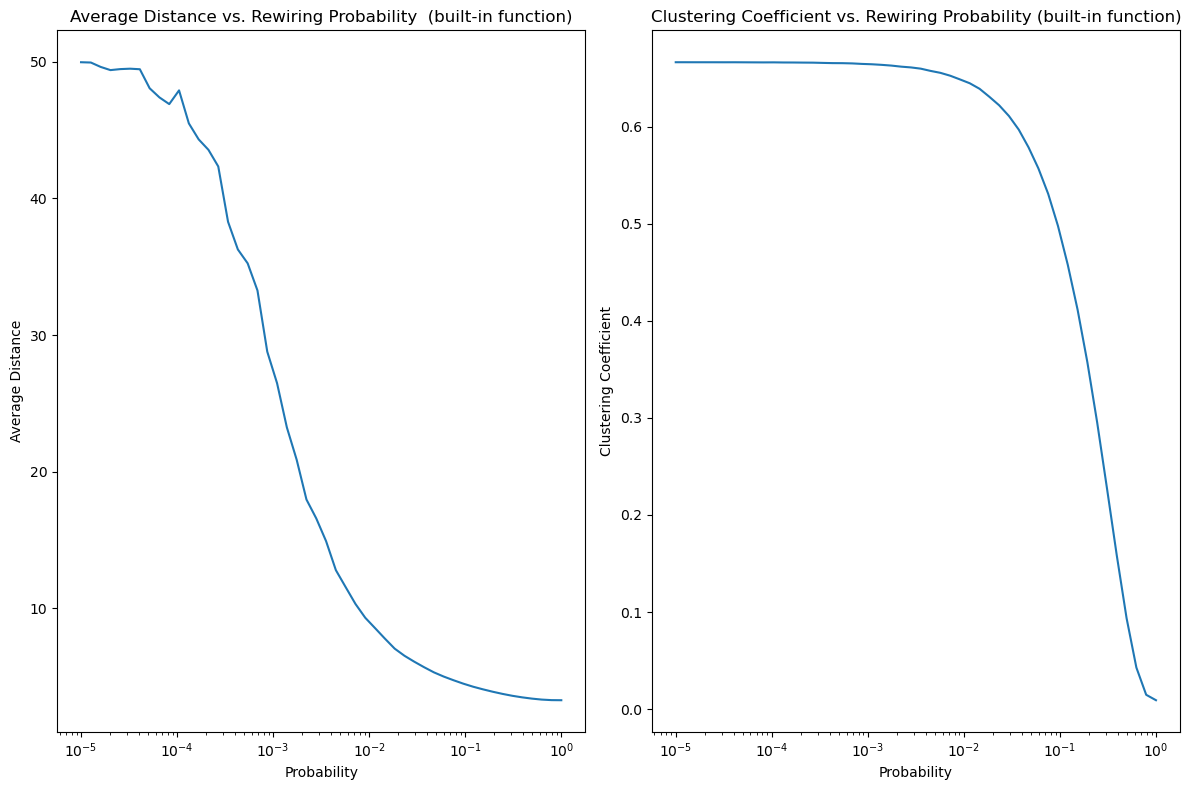

In [34]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.semilogx(probabilities_log_range, avg_shortest_path_averages_built_in.values())
plt.xlabel('Probability')
plt.ylabel('Average Distance')
plt.title('Average Distance vs. Rewiring Probability  (built-in function)')

plt.subplot(1, 2, 2)
plt.semilogx(probabilities_log_range, avg_clustering_coefficients_built_in.values())
plt.xlabel('Probability')
plt.ylabel('Clustering Coefficient')
plt.title('Clustering Coefficient vs. Rewiring Probability (built-in function)')
plt.tight_layout()

file_name = f"watts_strogatz_model_built_in_average_paths_and_communities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

# III Community Detection

## 1. For the provided network datasets find the communities using
 - (a) the greedy modularity maximization by Clauset Newman and Moore Clauset et al. [2004] and
 - (b) the label propagation algorithm.

Assign to each community a color and draw the resulting graph, where each node is colored after the community it belongs to, while community internal links and inter-communities links are clearly recognizable.

In [35]:
graphs

{'graph_internet': <networkx.classes.graph.Graph at 0x12275bfd0>,
 'graph_Korea': <networkx.classes.graph.Graph at 0x1200d3710>,
 'graph_eu_airlines': <networkx.classes.graph.Graph at 0x120457cd0>,
 'graph_macaque': <networkx.classes.graph.Graph at 0x1201fcfd0>,
 'graph_hep-th': <networkx.classes.graph.Graph at 0x12a5cbfd0>,
 'graph_starwars': <networkx.classes.graph.Graph at 0x1220cbd50>,
 'graph_madrid': <networkx.classes.graph.Graph at 0x1222d3d50>}

In [36]:
CONSIDERED_GRAPHS = ['graph_madrid', 'graph_starwars', 'graph_Korea']

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/3636630277.py:31: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)


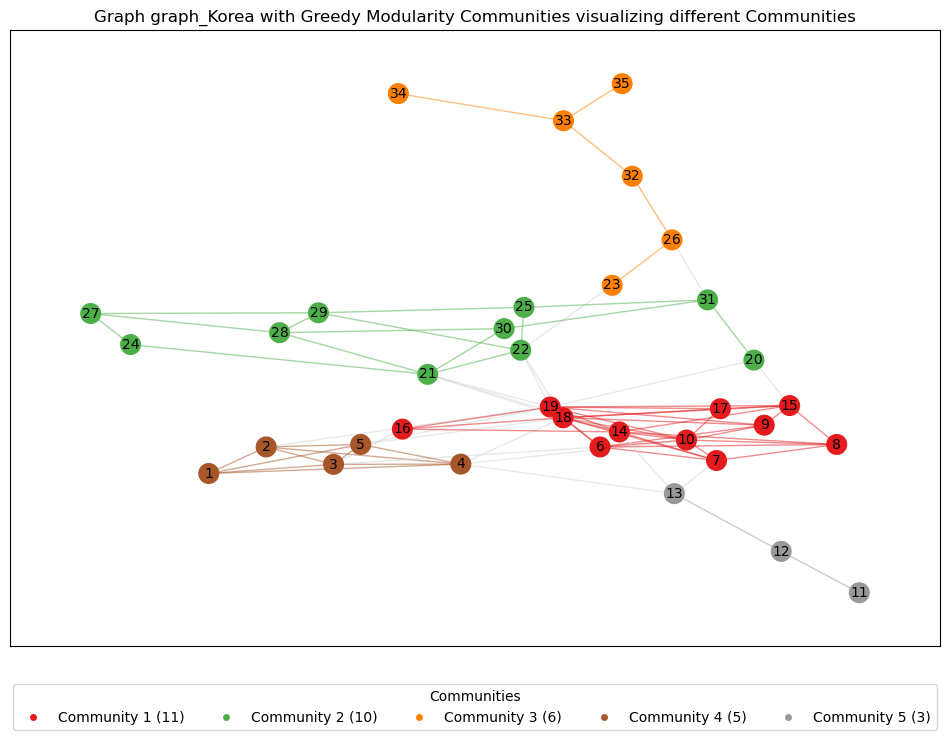

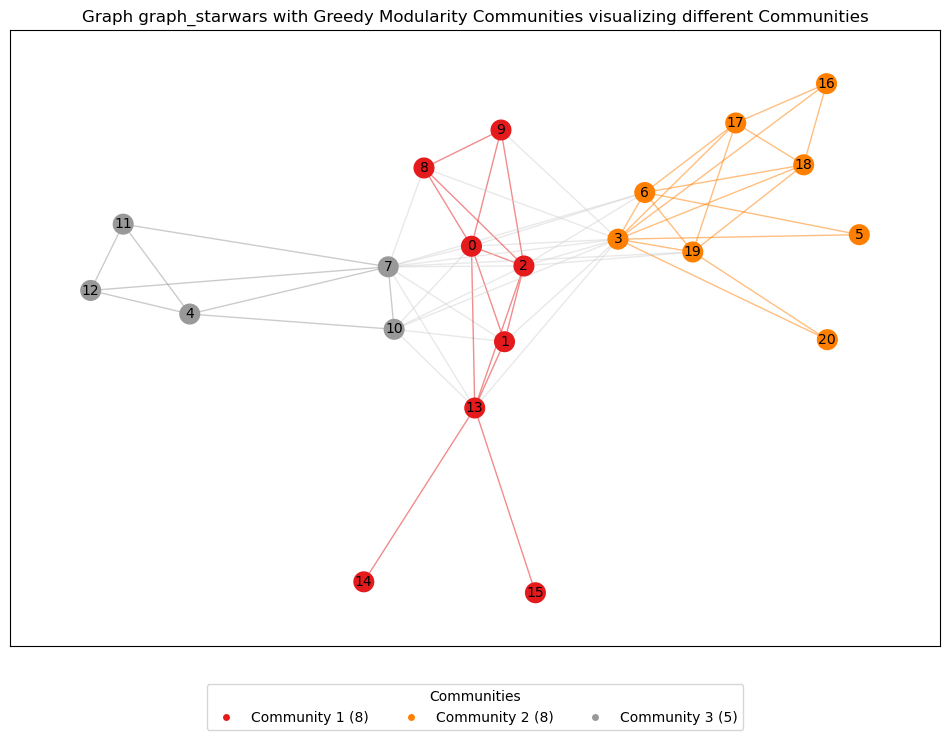

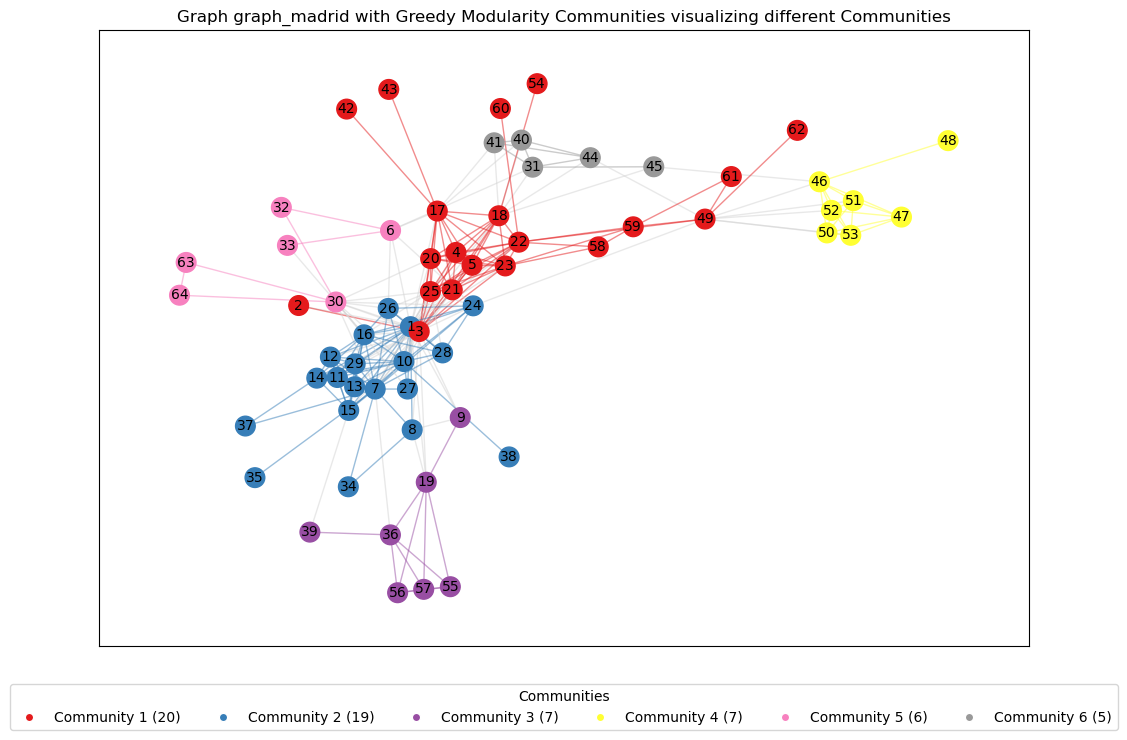

In [37]:
for graph_name, graph in graphs.items():
    
    if graph_name in CONSIDERED_GRAPHS:
        # Find communities using the greedy modularity maximization algorithm
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.modularity_max.greedy_modularity_communities.html
        communities = list(nx.community.greedy_modularity_communities(graph))
        
        # Create a dictionary to map nodes to their respective community
        community_dict = {}
        for i, community in enumerate(communities):
            for node in community:
                community_dict[node] = i
        
        # Create a list of colors for nodes based on their community
        node_colors = [community_dict[node] for node in graph.nodes]
        
        plt.figure(figsize=(12, 8))
        
        # Create a color map for inter-community edges
        cmap = plt.get_cmap('Set1', len(communities))
        
        # Create a list of edge colors based on community assignments
        # Inner edge: community color (cmap)
        # Outside edge: grey
        edge_colors = [cmap(community_dict[u]) if community_dict[u] == community_dict[v] else COLOR_LIGHT_GRAY for u, v in graph.edges]
        
        # Visualize the graph with community colors and distinguish internal and inter-community links
        pos = nx.spring_layout(graph, seed=42)  # Layout for visualization
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors, cmap=cmap, node_size=200)
        nx.draw_networkx_labels(graph, pos, font_size=10)
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)
        plt.title(f"Graph {graph_name} with Greedy Modularity Communities visualizing different Communities")
        
        
        # Create a legend for communities with the corresponding colors and node counts
        legend_labels = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities)]
        legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels)]
        
        # Set the bbox_to_anchor to place the legend outside the plotting area at the bottom in a straight line
        plt.legend(handles=legend_handles, title="Communities", loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels))

        
        
        file_name = f"greedy_modularity_communities_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_COMMUNITIES, file_name)
        plt.savefig(complete_plot_filename)
        plt.show()
    else:
        pass

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/3615388165.py:31: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)


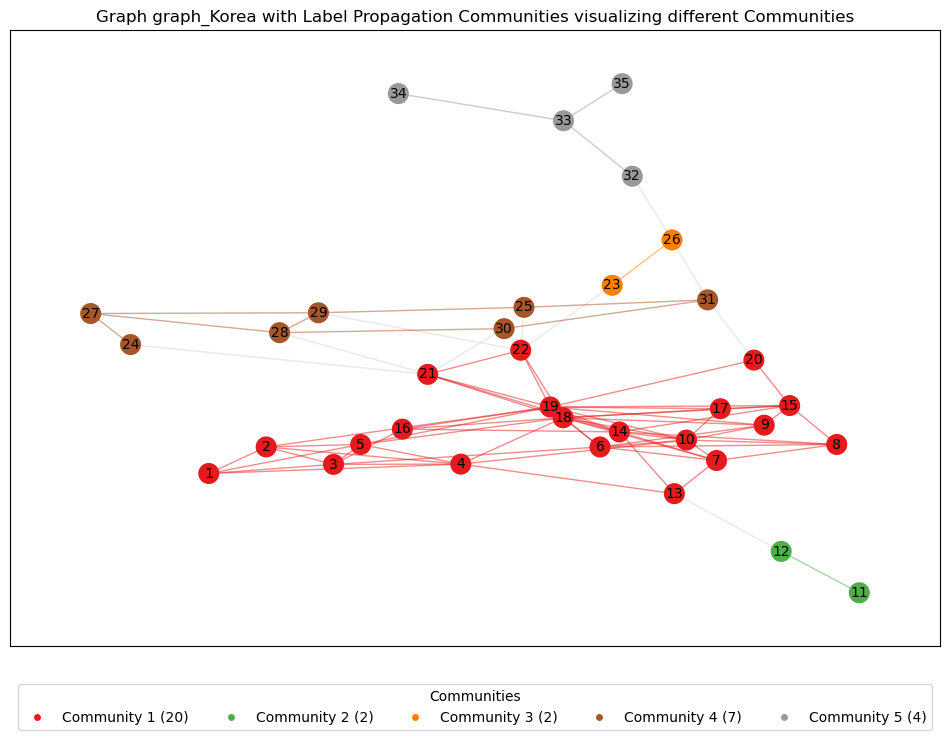

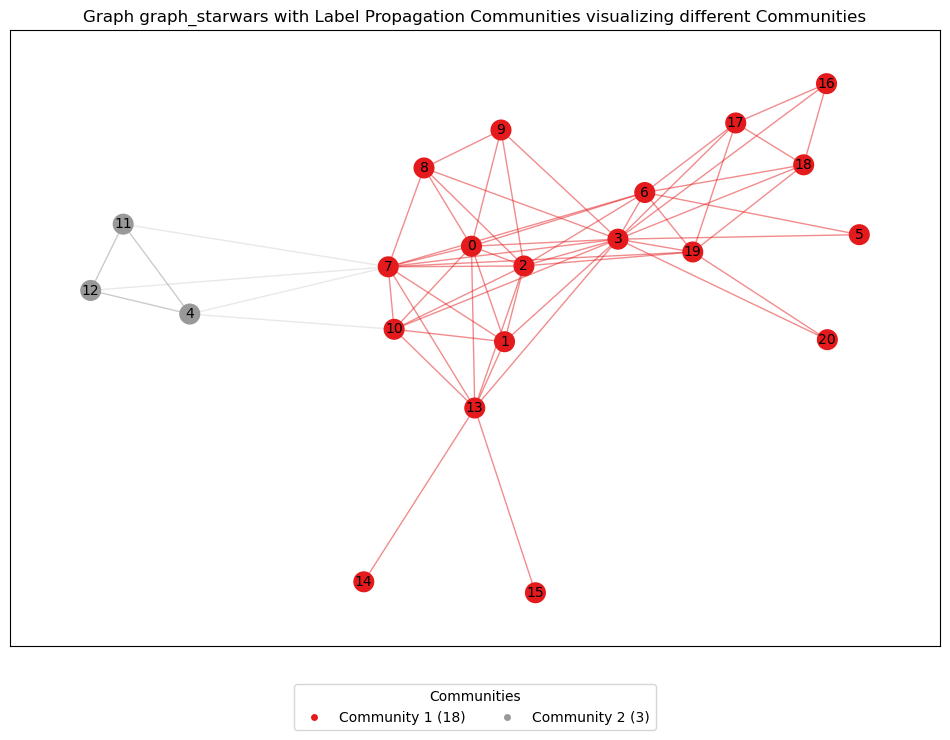

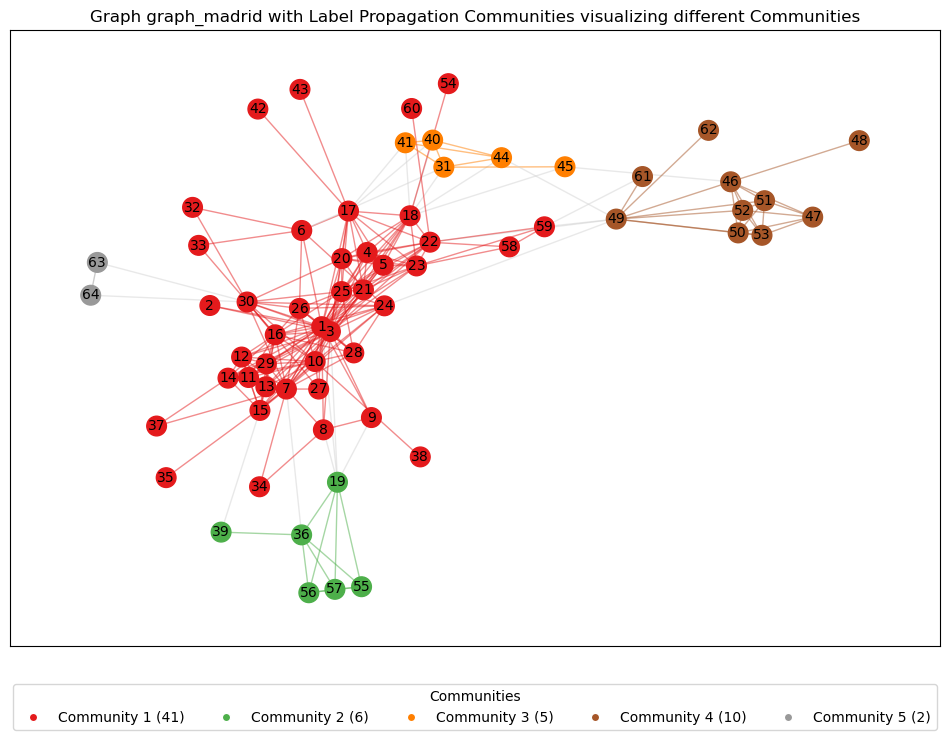

In [38]:
for graph_name, graph in graphs.items():
    
    if graph_name in CONSIDERED_GRAPHS:
        # Find communities using the greedy modularity maximization algorithm
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.label_propagation.label_propagation_communities.html
        communities = list(nx.community.label_propagation_communities(graph))
        
        # Create a dictionary to map nodes to their respective community
        community_dict = {}
        for i, community in enumerate(communities):
            for node in community:
                community_dict[node] = i
        
        # Create a list of colors for nodes based on their community
        node_colors = [community_dict[node] for node in graph.nodes]
        
        plt.figure(figsize=(12, 8))
        
        # Create a color map for inter-community edges
        cmap = plt.get_cmap('Set1', len(communities))
        
        # Create a list of edge colors based on community assignments
        # Inner edge: community color (cmap)
        # Outside edge: grey
        edge_colors = [cmap(community_dict[u]) if community_dict[u] == community_dict[v] else COLOR_LIGHT_GRAY for u, v in graph.edges]
        
        # Visualize the graph with community colors and distinguish internal and inter-community links
        pos = nx.spring_layout(graph, seed=42)  # Layout for visualization
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors, cmap=cmap, node_size=200)
        nx.draw_networkx_labels(graph, pos, font_size=10)
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)
        plt.title(f"Graph {graph_name} with Label Propagation Communities visualizing different Communities")
        
        
        # Create a legend for communities with the corresponding colors and node counts
        legend_labels = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities)]
        legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels)]
        
        # Set the bbox_to_anchor to place the legend outside the plotting area at the bottom in a straight line
        plt.legend(handles=legend_handles, title="Communities", loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels))

        
        
        file_name = f"label_propagation_communities_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_COMMUNITIES, file_name)
        plt.savefig(complete_plot_filename)
        plt.show()
    else:
        pass

/usr/local/anaconda3/envs/network-science/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/2056149498.py:36: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors_lp, alpha=0.5, ax=axes[0])
/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/2056149498.py:43: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors_greedy, alpha=0.5, ax=axes[1])


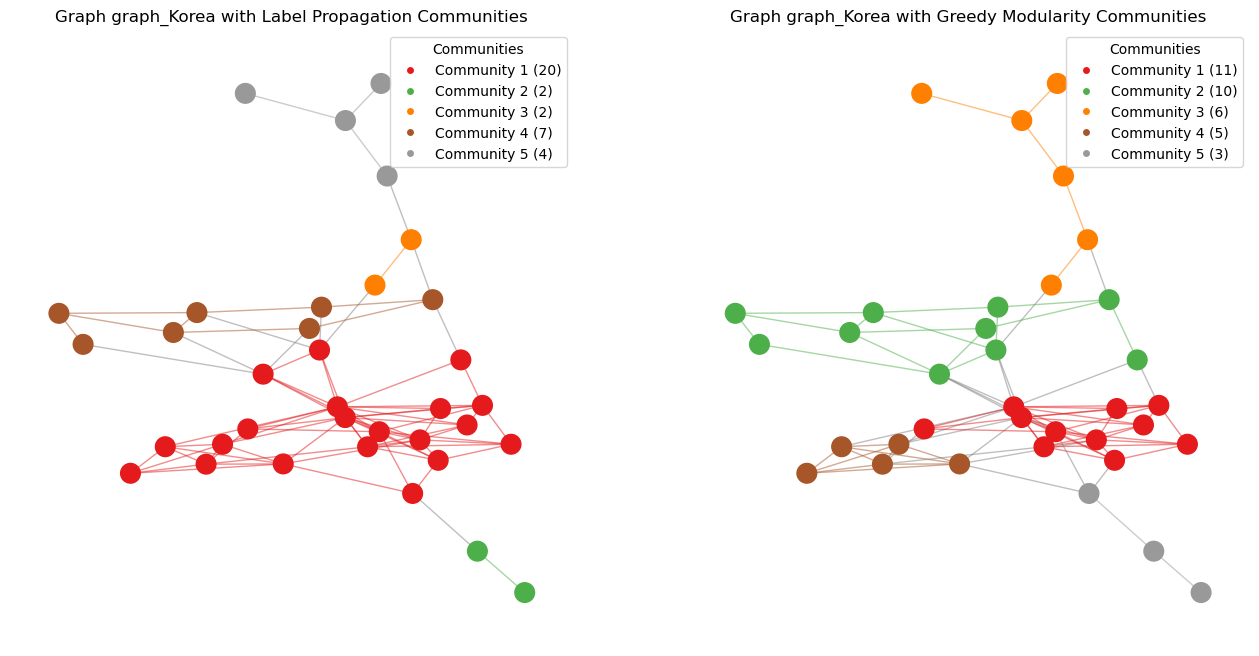

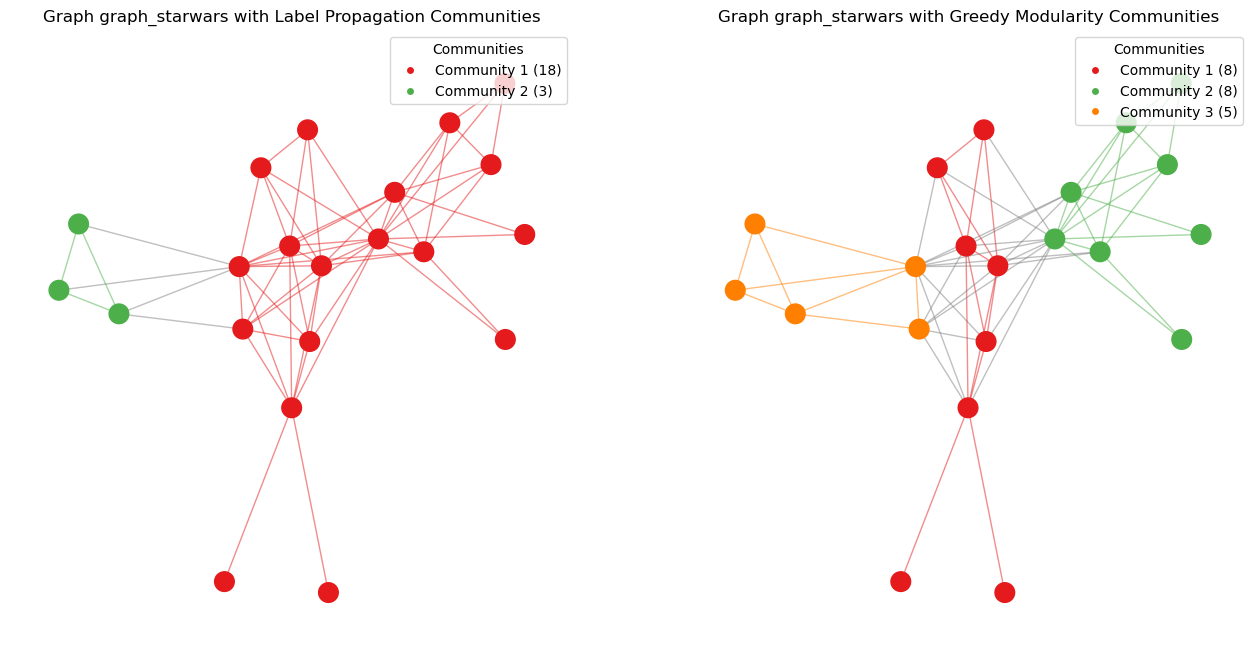

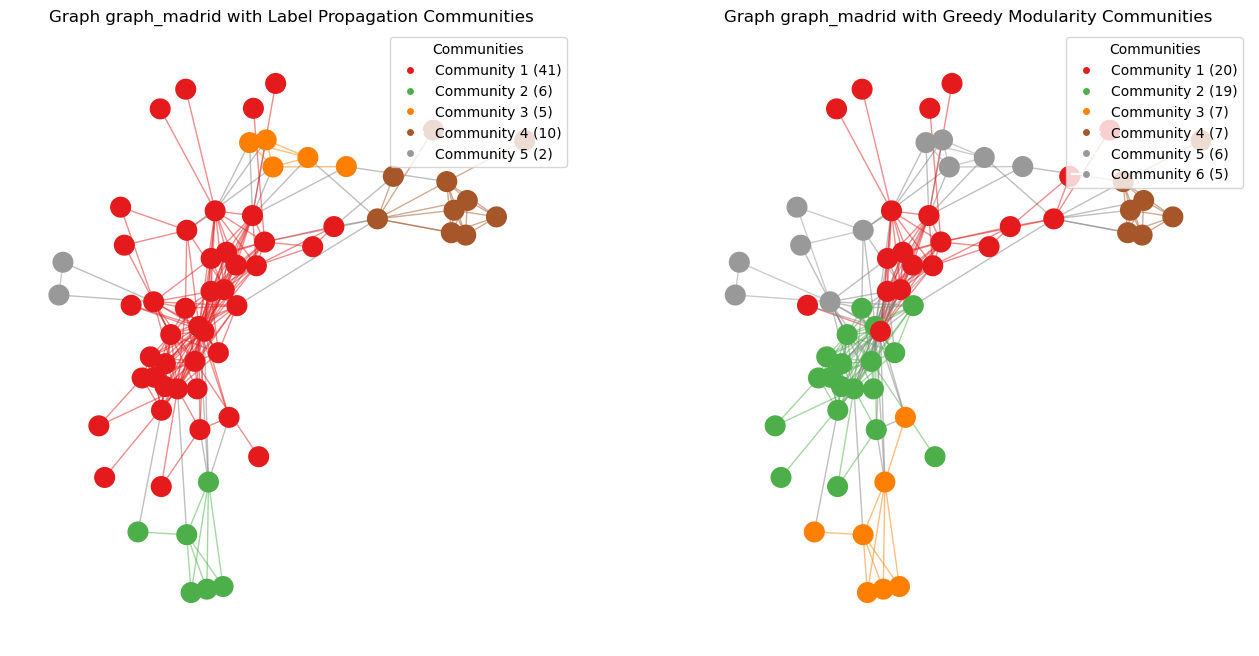

In [39]:
# Loop through the graphs
for graph_name, graph in graphs.items():
    if graph_name in CONSIDERED_GRAPHS:
        # Find communities using the label propagation algorithm
        communities_lp = list(nx.community.label_propagation_communities(graph))
        # Find communities using the greedy modularity maximization algorithm
        communities_greedy = list(nx.community.greedy_modularity_communities(graph))

        # Create a dictionary to map nodes to their respective community for label propagation
        community_dict_lp = {}
        for i, community in enumerate(communities_lp):
            for node in community:
                community_dict_lp[node] = i

        # Create a dictionary to map nodes to their respective community for greedy modularity
        community_dict_greedy = {}
        for i, community in enumerate(communities_greedy):
            for node in community:
                community_dict_greedy[node] = i

        # Create a list of colors for nodes based on their community for label propagation
        node_colors_lp = [cmap(community_dict_lp[node]) for node in graph.nodes]

        # Create a list of colors for nodes based on their community for greedy modularity
        node_colors_greedy = [cmap(community_dict_greedy[node]) for node in graph.nodes]

        # Create subplots to display both label propagation and greedy modularity communities
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # Visualize label propagation communities
        pos = nx.spring_layout(graph, seed=42)  # Layout for visualization
        edge_colors_lp = [cmap(community_dict_lp[u]) if community_dict_lp[u] == community_dict_lp[v] else 'gray' for u, v in graph.edges]
        axes[0].set_title(f"Graph {graph_name} with Label Propagation Communities")
        axes[0].set_axis_off()
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors_lp, cmap=cmap, node_size=200, ax=axes[0])
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors_lp, alpha=0.5, ax=axes[0])

        # Visualize greedy modularity communities
        edge_colors_greedy = [cmap(community_dict_greedy[u]) if community_dict_greedy[u] == community_dict_greedy[v] else 'gray' for u, v in graph.edges]
        axes[1].set_title(f"Graph {graph_name} with Greedy Modularity Communities")
        axes[1].set_axis_off()
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors_greedy, cmap=cmap, node_size=200, ax=axes[1])
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors_greedy, alpha=0.5, ax=axes[1])

        # Create a legend for label propagation communities
        legend_labels_lp = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities_lp)]
        legend_handles_lp = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels_lp)]
        axes[0].legend(handles=legend_handles_lp, title="Communities", loc='upper right', bbox_to_anchor=(1.0, 1.0), ncol=1)

        # Create a legend for greedy modularity communities
        legend_labels_greedy = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities_greedy)]
        legend_handles_greedy = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels_greedy)]
        axes[1].legend(handles=legend_handles_greedy, title="Communities", loc='upper right', bbox_to_anchor=(1.0, 1.0), ncol=1)

        # Save the plot
        file_name = f"communities_comparison_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_COMMUNITIES, file_name)
        plt.savefig(complete_plot_filename, bbox_inches='tight')
        plt.show()
    else:
        pass


## 2. Randomise each network and repeat the exercise at point (1).

Compare the number of communities obtained before and after randomisation and the quality of community detection before and after randomisation.

In [40]:
random_graphs = graphs.copy()

for graph_name, g in random_graphs.items():
    random_graphs[graph_name] = nx.algorithms.smallworld.random_reference(G=g, niter=10, connectivity=False, seed=SEED)

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/3617236443.py:31: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)


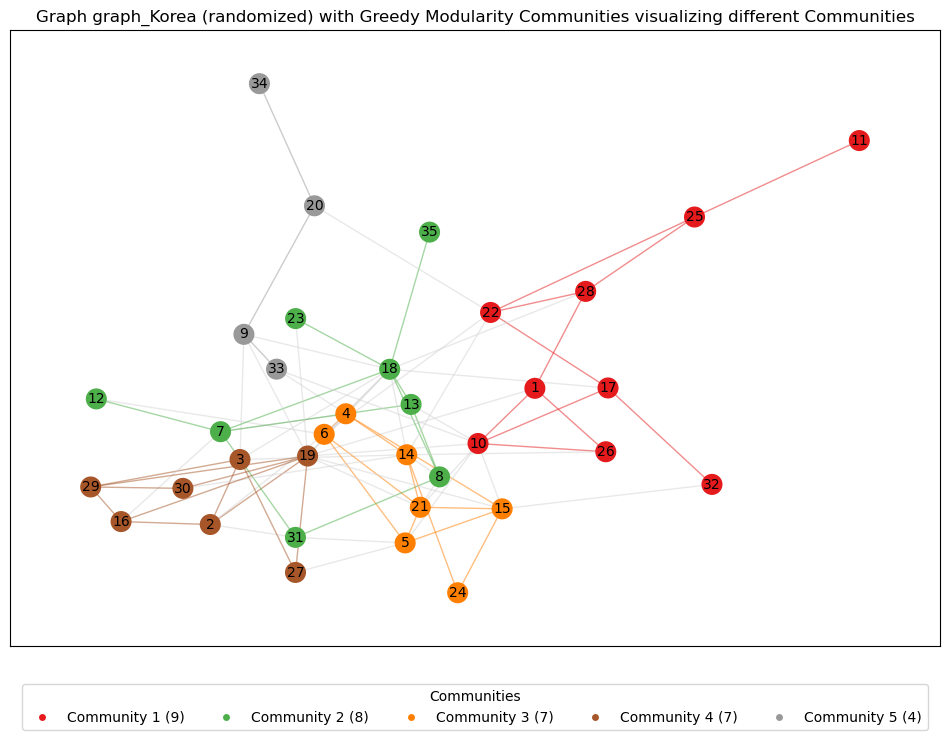

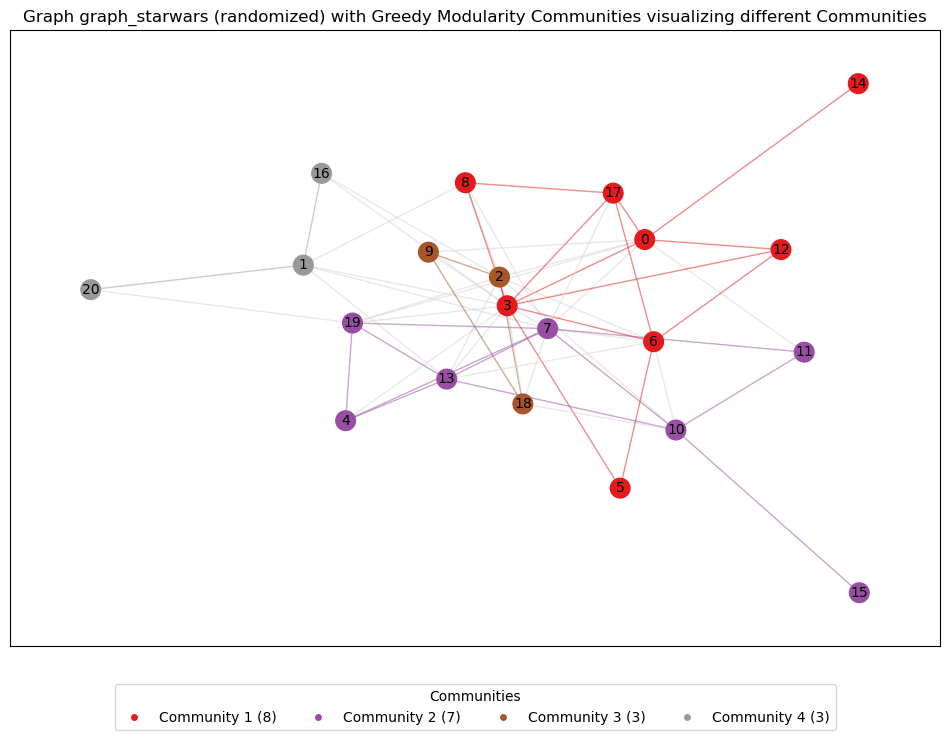

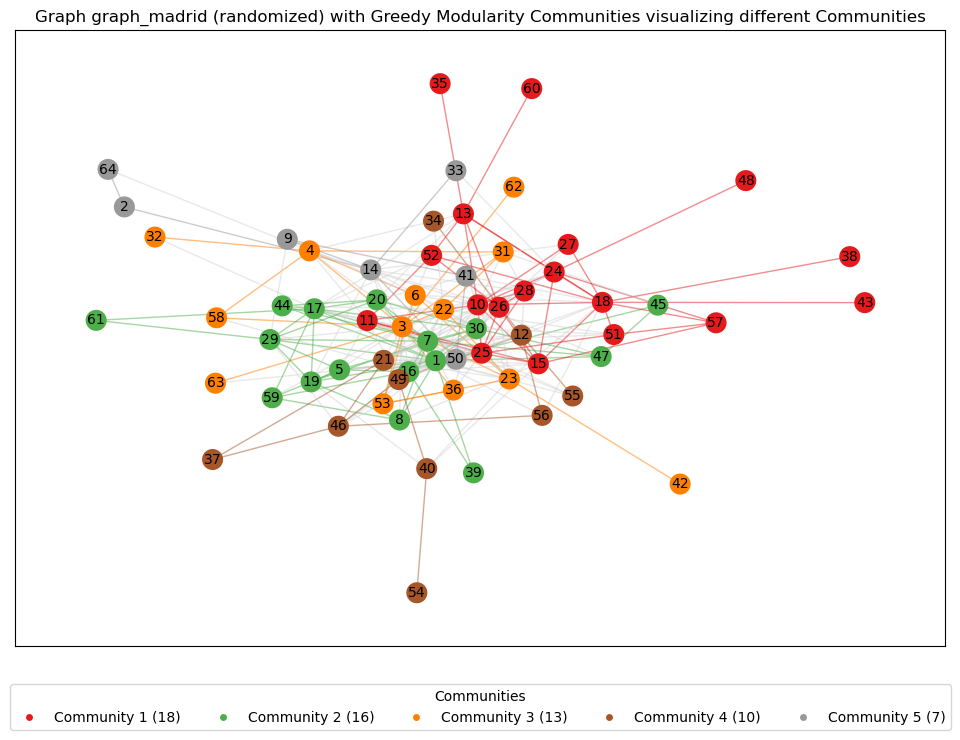

In [41]:
for graph_name, graph in random_graphs.items():
    
    if graph_name in CONSIDERED_GRAPHS:
        # Find communities using the greedy modularity maximization algorithm
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.modularity_max.greedy_modularity_communities.html
        communities = list(nx.community.greedy_modularity_communities(graph))
        
        # Create a dictionary to map nodes to their respective community
        community_dict = {}
        for i, community in enumerate(communities):
            for node in community:
                community_dict[node] = i
        
        # Create a list of colors for nodes based on their community
        node_colors = [community_dict[node] for node in graph.nodes]
        
        plt.figure(figsize=(12, 8))
        
        # Create a color map for inter-community edges
        cmap = plt.get_cmap('Set1', len(communities))
        
        # Create a list of edge colors based on community assignments
        # Inner edge: community color (cmap)
        # Outside edge: grey
        edge_colors = [cmap(community_dict[u]) if community_dict[u] == community_dict[v] else COLOR_LIGHT_GRAY for u, v in graph.edges]
        
        # Visualize the graph with community colors and distinguish internal and inter-community links
        pos = nx.spring_layout(graph, seed=42)  # Layout for visualization
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors, cmap=cmap, node_size=200)
        nx.draw_networkx_labels(graph, pos, font_size=10)
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)
        plt.title(f"Graph {graph_name} (randomized) with Greedy Modularity Communities visualizing different Communities")
        
        
        # Create a legend for communities with the corresponding colors and node counts
        legend_labels = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities)]
        legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels)]
        
        # Set the bbox_to_anchor to place the legend outside the plotting area at the bottom in a straight line
        plt.legend(handles=legend_handles, title="Communities", loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels))

        
        
        file_name = f"greedy_modularity_communities_randomized_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_COMMUNITIES, file_name)
        plt.savefig(complete_plot_filename)
        plt.show()
    else:
        pass

/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/3164377424.py:31: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)


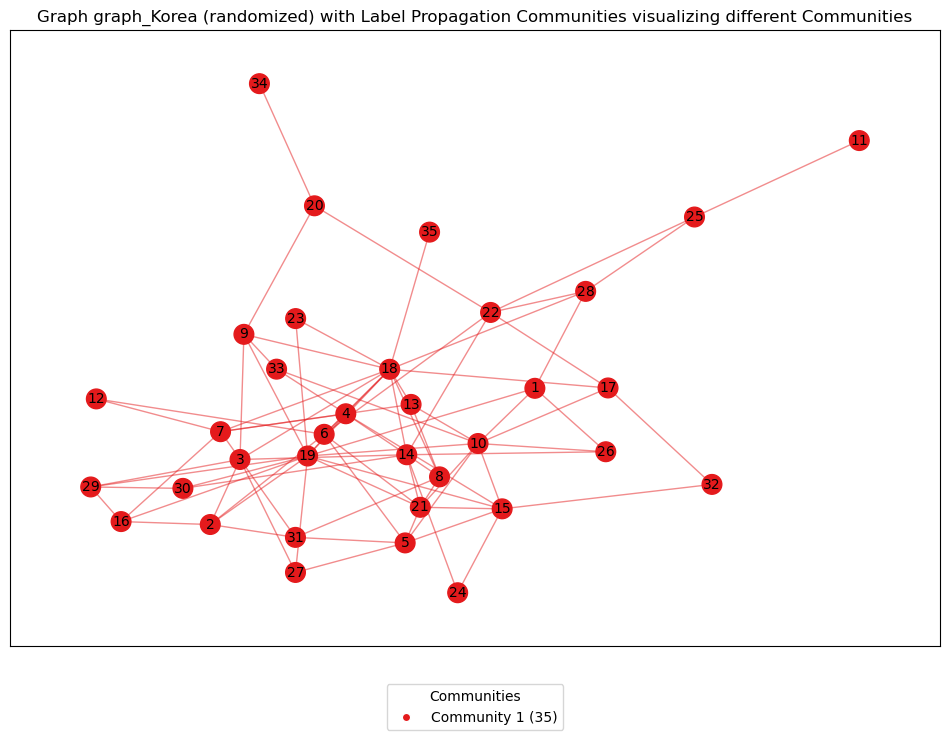

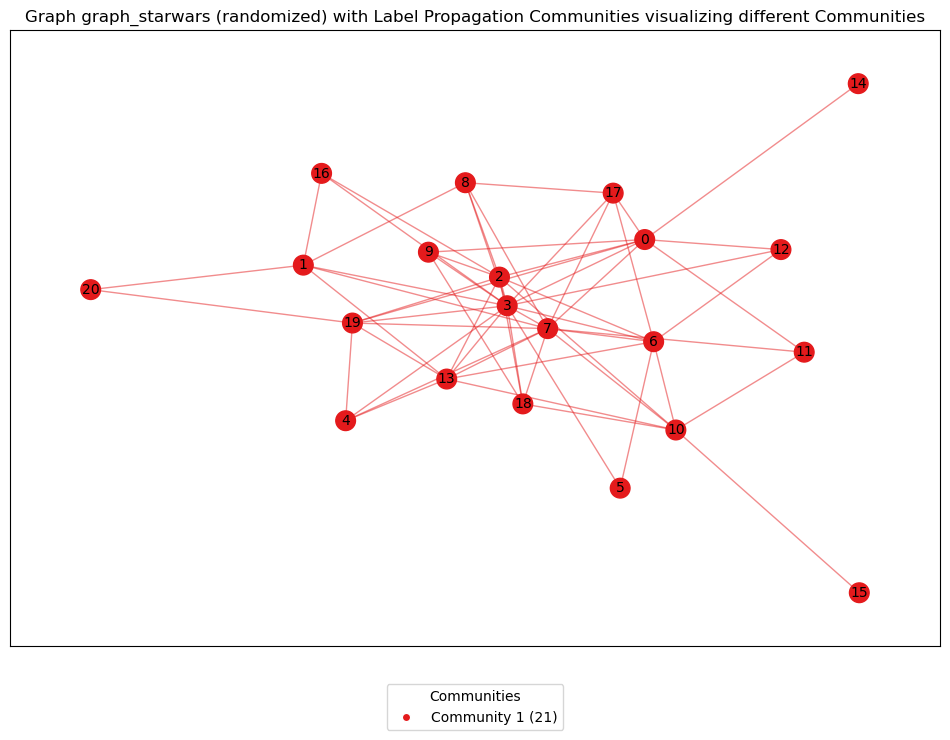

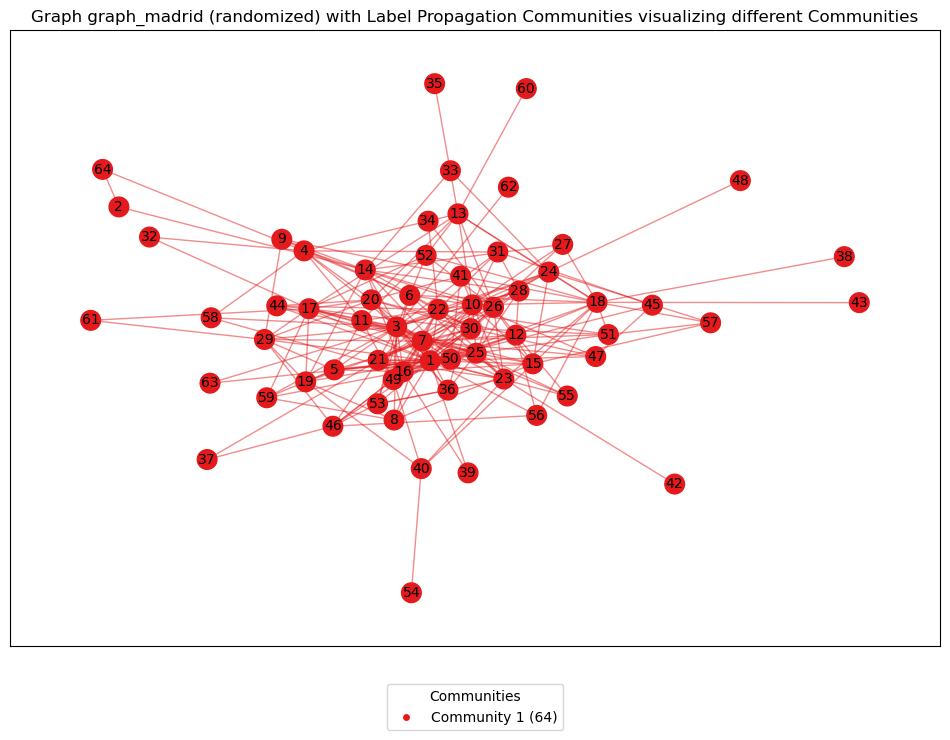

In [42]:
for graph_name, graph in random_graphs.items():
    
    if graph_name in CONSIDERED_GRAPHS:
        # Find communities using the greedy modularity maximization algorithm
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.label_propagation.label_propagation_communities.html
        communities = list(nx.community.label_propagation_communities(graph))
        
        # Create a dictionary to map nodes to their respective community
        community_dict = {}
        for i, community in enumerate(communities):
            for node in community:
                community_dict[node] = i
        
        # Create a list of colors for nodes based on their community
        node_colors = [community_dict[node] for node in graph.nodes]
        
        plt.figure(figsize=(12, 8))
        
        # Create a color map for inter-community edges
        cmap = plt.get_cmap('Set1', len(communities))
        
        # Create a list of edge colors based on community assignments
        # Inner edge: community color (cmap)
        # Outside edge: grey
        edge_colors = [cmap(community_dict[u]) if community_dict[u] == community_dict[v] else COLOR_LIGHT_GRAY for u, v in graph.edges]
        
        # Visualize the graph with community colors and distinguish internal and inter-community links
        pos = nx.spring_layout(graph, seed=42)  # Layout for visualization
        nx.draw_networkx_nodes(graph, pos, node_color=node_colors, cmap=cmap, node_size=200)
        nx.draw_networkx_labels(graph, pos, font_size=10)
        nx.draw_networkx_edges(graph, pos, edge_color=edge_colors, alpha=0.5)
        plt.title(f"Graph {graph_name} (randomized) with Label Propagation Communities visualizing different Communities")
        
        
        # Create a legend for communities with the corresponding colors and node counts
        legend_labels = [f"Community {i+1} ({len(community)})" for i, community in enumerate(communities)]
        legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=cmap(i)) for i, label in enumerate(legend_labels)]
        
        # Set the bbox_to_anchor to place the legend outside the plotting area at the bottom in a straight line
        plt.legend(handles=legend_handles, title="Communities", loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels))

        
        
        file_name = f"label_propagation_communities_randomized_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_COMMUNITIES, file_name)
        plt.savefig(complete_plot_filename)
        plt.show()
    else:
        pass

# IV Power-Laws

## 1. Compute the exponent $γ$ of the power-law distribution fit $p(k) ∼ k^{−γ}$ of the network degree distribution and the corresponding error.

In [43]:
CONSIDERED_GRAPHS = ['graph_eu_airlines', 'graph_macaque', 'graph_internet', 'graph_starwars', 'graph_hep-th']

In [44]:
def gamma_dist(graph):
    degrees = [d for n, d in graph.degree()]

    # Fit a power-law distribution to your data
    # https://github.com/jeffalstott/powerlaw
    fit = powerlaw.Fit(data = degrees)
    
    # Estimated exponent gamma
    gamma = fit.power_law.alpha
    
    
    # Calculate standard error of estimated exponent gamma
    gamma_error = fit.power_law.sigma
    
    return (gamma, gamma_error)

In [45]:
for graph_name, graph in graphs.items():

    if graph_name in CONSIDERED_GRAPHS:
        gamma, gamma_error = gamma_dist(graph=graph)
        print(f"Gamma of the power-law distribution fit from graph {graph_name}: {gamma:.4f}. Corresponding error: {gamma_error:.4f}")

Calculating best minimal value for power law fit
/usr/local/anaconda3/envs/network-science/lib/python3.11/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


Gamma of the power-law distribution fit from graph graph_internet: 2.1122. Corresponding error: 0.0367
Gamma of the power-law distribution fit from graph graph_eu_airlines: 2.2049. Corresponding error: 0.1086
Gamma of the power-law distribution fit from graph graph_macaque: 17.0449. Corresponding error: 4.0112
Gamma of the power-law distribution fit from graph graph_hep-th: 3.2578. Corresponding error: 0.0635
Gamma of the power-law distribution fit from graph graph_starwars: 4.6762. Corresponding error: 1.2997


Calculating best minimal value for power law fit


## 2. Produce a single plot showing:
 - the empirical degree distribution,
 - the power-law fit,
 - the Poisson fit,
 - the exponential distribution with mean value equal to ⟨k⟩.

In [46]:
def degree_dist(g):
    degrees = sorted([d for n,d in g.degree()], reverse=True)
    degrees, counts = np.unique(degrees, return_counts=True)
    return degrees, counts

def average_degree(g):
    degree_sequence = [d for n, d in g.degree()]
    mu = np.mean(degree_sequence)
    return  mu
    #return sum(dict(g.degree()).values()) / g.number_of_nodes()


def plot_degree_dist(degrees, counts, label):
    plt.plot(degrees,counts, label=label)
    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Counts")
    plt.legend()

def poission_dist(mean, degree):
    # https://en.wikipedia.org/wiki/Poisson_distribution
    return (mean**degree / factorial(degree))*np.exp(-mean)

def exponential_dist(mean, degree):
    # https://en.wikipedia.org/wiki/Exponential_distribution
    return mean * np.exp(-degree / mean)

Calculating best minimal value for power law fit
/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/1678974088.py:22: RuntimeWarning: overflow encountered in power
  return (mean**degree / factorial(degree))*np.exp(-mean)
/var/folders/ck/vgxn_9f907d122j56f3203gm0000gn/T/ipykernel_71014/1678974088.py:22: RuntimeWarning: invalid value encountered in divide
  return (mean**degree / factorial(degree))*np.exp(-mean)


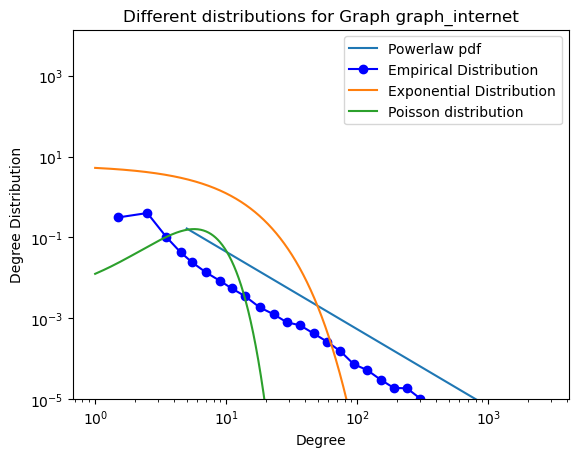

Calculating best minimal value for power law fit


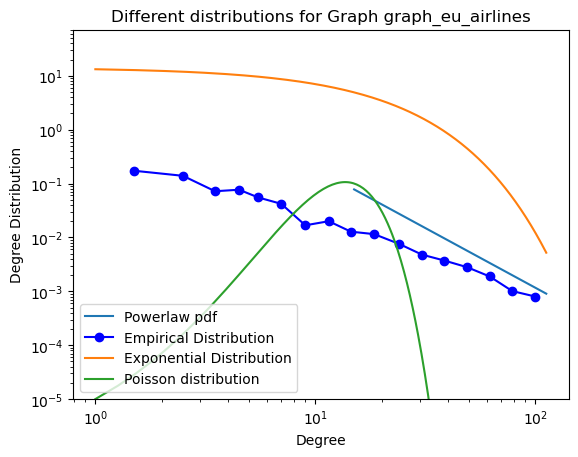

Calculating best minimal value for power law fit


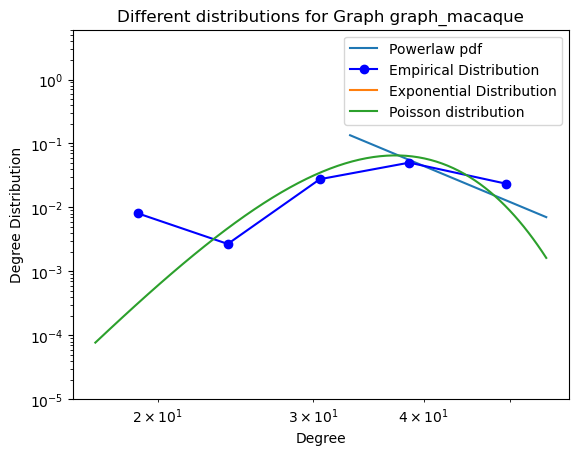

Calculating best minimal value for power law fit


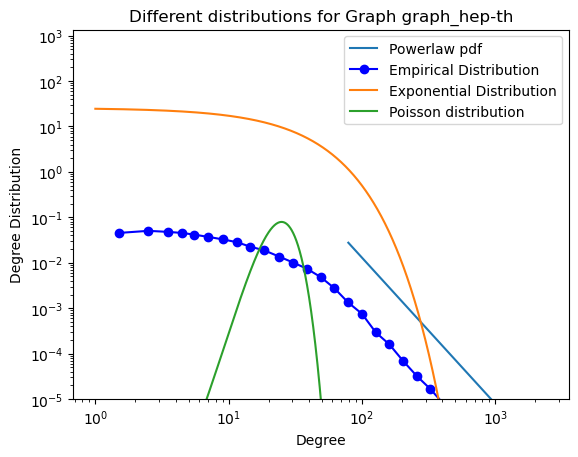

Calculating best minimal value for power law fit


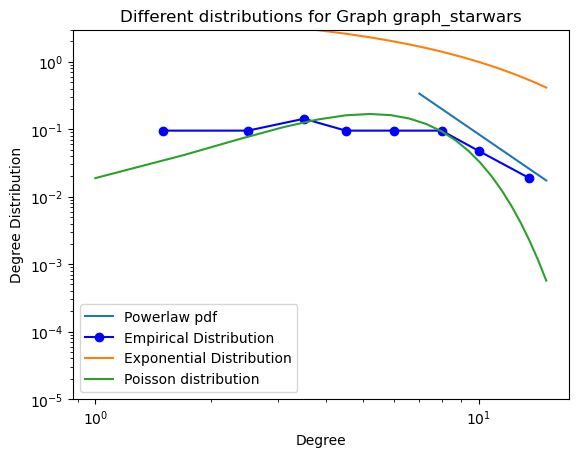

In [48]:
for graph_name, graph in graphs.items():

    if graph_name in CONSIDERED_GRAPHS:
        degrees, counts = degree_dist(graph)
        k = np.asarray([d for d in dict(graph.degree()).values()])
        spacing = np.linspace(min(k),max(k),len(k))
        fit = powerlaw.Fit(data=k, discrete=True)
        
        fit.power_law.plot_pdf(label="Powerlaw pdf")
        powerlaw.plot_pdf(k, color='b', marker='o', label="Empirical Distribution") # empirical one, do really plot the pdf
        #plot_degree_dist(degrees, counts, "Empirical Distribution") # DO NOT plot the degree dist.
        plt.loglog(spacing, exponential_dist(average_degree(graph),spacing), label="Exponential Distribution")
        plt.loglog(spacing, poission_dist(average_degree(graph), spacing), label="Poisson distribution")
        plt.title(f"Different distributions for Graph {graph_name}")
        plt.xlabel('Degree')
        plt.ylabel('Degree Distribution')
        plt.ylim(1e-5, max(counts))
        plt.legend()
        file_name = f"dist_plot_{graph_name}.png"
        complete_plot_filename = os.path.join(OUTPUT_PATH_POWER_LAWS, file_name)
        plt.savefig(complete_plot_filename)
        plt.show()
        

## 3. Provide a comment on the previous plot: based on the real-world origin of the network, explain why the network shows (or does not show) a scale-free behaviour.

In the graphs `graph_internet`, and `graph_hep` we can observe scale-free behavior because the slope of the empirical distribution matches with the powerlaw pdf fit.
In the graphs `graph_eu_airlines`, `graph_macaque`, and `graph_starwars` we can not observe scale-free behavior because the slope of the empirical distribution does not match with the powerlaw pdf fit. We classified `graph_eu_airlines` as non-scale-free because the the slopes are kind of similiar, but not as similar as `graph_internet`, and `graph_hep`.

Creating Results:
`jupyter nbconvert Assignment_02.ipynb --to pdf --output Assignment_02_Results.pdf`